## 1. Explore the data

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.under_sampling import EditedNearestNeighbours, RandomUnderSampler
from imblearn.pipeline import make_pipeline

# Display settings
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns', None)

In [2]:
# 2. Load the data
file_path = "../data/raw/All_Beauty.jsonl"
data = pd.read_json(file_path, lines=True)

In [3]:
# 3. Shape and Preview Data
data.shape

(701528, 10)

In [4]:
data.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,"This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, med...",[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just wish it was odorless or had a soft coconut smell. Having my head smell like an orange coffee is offputting. (granted, I did know the smell was descri...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [5]:
# 4. Inspect Columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701528 entries, 0 to 701527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             701528 non-null  int64         
 1   title              701528 non-null  object        
 2   text               701528 non-null  object        
 3   images             701528 non-null  object        
 4   asin               701528 non-null  object        
 5   parent_asin        701528 non-null  object        
 6   user_id            701528 non-null  object        
 7   timestamp          701528 non-null  datetime64[ns]
 8   helpful_vote       701528 non-null  int64         
 9   verified_purchase  701528 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 48.8+ MB


In [6]:
# 5. Check for missing and duplicate values
data.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [7]:
data.duplicated(subset=['title', 'text', 'user_id']).sum()

np.int64(7999)

In [8]:
# Handle duplicates
data = data.drop_duplicates(subset=['title', 'text', 'user_id'])

In [9]:
data.shape

(693529, 10)

In [10]:
# 6. Preview Label Distribution
data['rating'].value_counts(normalize=True)

rating
5    0.599593
1    0.145427
4    0.113258
3    0.080307
2    0.061415
Name: proportion, dtype: float64

In [11]:
# Create valence categories
def map_valence(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

data['sentiment'] = data['rating'].apply(map_valence)
data['sentiment'].value_counts()
data['sentiment'].value_counts(normalize=True)

sentiment
positive    0.712851
negative    0.206842
neutral     0.080307
Name: proportion, dtype: float64

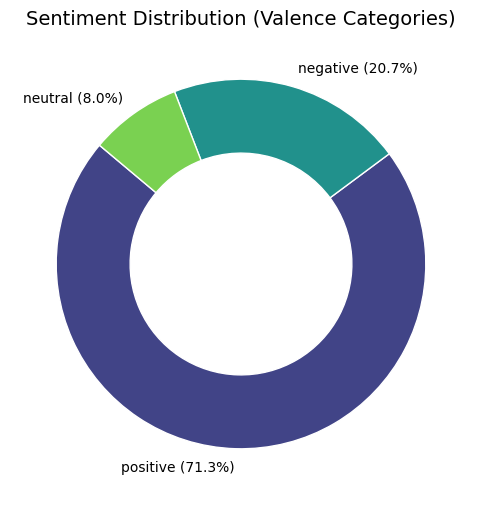

In [12]:
# 7. Check and Visualize Imbalanced Classes
sentiment_counts = data['sentiment'].value_counts()
sentiment_percent = data['sentiment'].value_counts(normalize=True) * 100
labels = [f'{label} ({percent:.1f}%)' for label, percent in zip(sentiment_counts.index, sentiment_percent)]
colors = plt.cm.viridis([0.2, 0.5, 0.8]) 

# Create donut chart
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts = ax.pie(sentiment_counts,
                       labels=labels,
                       colors=colors,
                       startangle=140,
                       wedgeprops=dict(width=0.4)) 
plt.setp(wedges, edgecolor='white')
ax.set_title('Sentiment Distribution (Valence Categories)', fontsize=14)
plt.show()

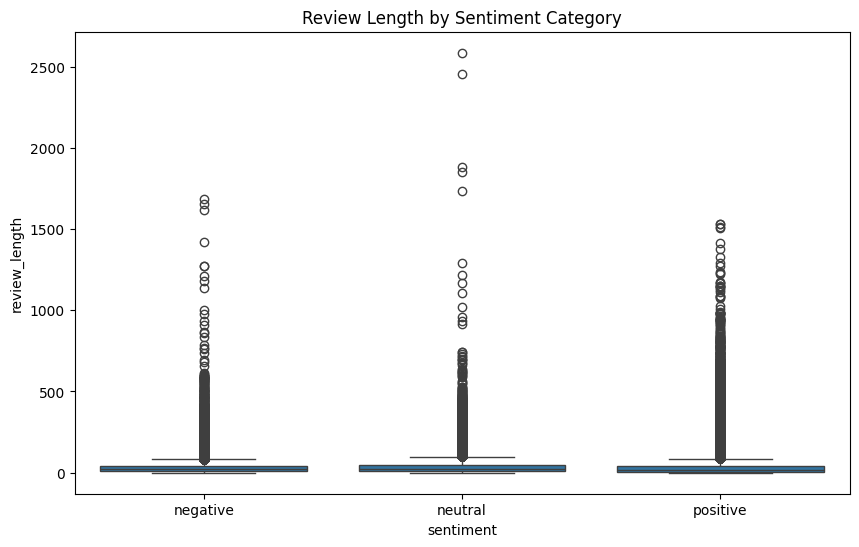

In [13]:
# 8. Visualize Review Length Distribution
data['review_length'] = data['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='sentiment', y='review_length', order=['negative','neutral','positive'])
plt.title("Review Length by Sentiment Category")
plt.show()

## 2. Text Processing

- Clean the review text (remove URLs, emojis, HTML, spaces)
- Create a clean_review column
- Verify cleaning works 

In [21]:
# 9. Text Processing
def clean_text(text):
    text = str(text).lower()  # lowercase
    text = emoji.replace_emoji(text, replace='') #remove emojis
    text = re.sub(r"http\S+|www\S+", "", text)      # remove URLs
    text = re.sub(r"<.*?>", "", text)               # remove HTML tags
    text = re.sub(r"[^a-zA-Z0-9\s\.,!?'\":;()\-\"\n]", "", text) # keep letters, numbers, basic punctuation
    text = re.sub(r"\s+", " ", text).strip()        # remove extra spaces
    return text

data['clean_review'] = data['text'].apply(clean_text)

In [22]:
data[['text', 'clean_review']].sample(5, random_state=42)

,text,clean_review
570199,It smells really good. It doesn't leave your skin oily like other scrubs. And it works great before shaving.,it smells really good. it doesn't leave your skin oily like other scrubs. and it works great before shaving.
178812,Great brush for the price however does not last long,great brush for the price however does not last long
665318,Best product at a cheap price and item arrived in less than 5 days AAA+++ thanks,best product at a cheap price and item arrived in less than 5 days aaa thanks
485544,I love it.,i love it.
446181,It's so nice to have my jars laying on their sides so I can see the colors at a glance. I use to have to dig through my cosmetic bag every morning and wasted so many valuable minutes while rushin...,it's so nice to have my jars laying on their sides so i can see the colors at a glance. i use to have to dig through my cosmetic bag every morning and wasted so many valuable minutes while rushing...


In [23]:
# show first 5 cleaned reviews
data.shape

(692043, 13)

In [24]:
# Remove empty string rows in 'clean_review' and sentiment column
data = data[data['clean_review'].str.strip() != '']
data.shape

(692043, 13)

In [25]:
# Save cleaned_reviews
data[["clean_review", "sentiment"]].to_csv(
    "../data/processed/cleaned_reviews.csv", index=False
)